# Trabajando con texto (strings)

## 01\. Introducción

En esta lección, aprenderemos un par de otras tareas de limpieza de texto, como:

*   Encontrar cadenas específicas o subcadenas en columnas
*   Extracción de subcadenas de datos no estructurados
*   Eliminar cadenas o subcadenas de una serie

A medida que aprendamos estas tareas, también trabajaremos para generar intuición sobre cómo funcionan estos métodos de cadena para que pueda explorar métodos que no hemos cubierto explícitamente por su cuenta.

Trabajaremos nuevamente con el Informe sobre [la felicidad en el mundo 2015](https://drive.google.com/uc?id=1JexbQAX-5KrQs-lzDXXAYBicYlUQjOo_&export=download) _y_ datos económicos adicionales del Banco Mundial. Puede encontrar el conjunto de datos [aquí](https://drive.google.com/uc?id=1qVVDdOwOjcfjjrJUPX1gcgXEy_vn3sGI&export=download).

*   `ShortName` - Nombre del país
*   `Region` - La región a la que pertenece el país
*   `IncomeGroup`: el grupo de ingresos al que pertenece el país, según el ingreso nacional bruto (GNI) per cápita
*   `CurrencyUnit` - Nombre de la moneda del país
*   `SourceOfMostRecentIncomeAndExpenditureData`: el nombre de la encuesta utilizada para recopilar los datos de ingresos y gastos
*   `SpecialNotes`: contiene notas misceláneas sobre los datos

### Ejercicio

Ya hemos leído `World_Happiness_2015.csv` en un dataframe llamado `happiness2015` y `World_dev.csv` en un dataframe llamado `world_dev`.

In [7]:
from pprint import pprint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
happiness2015 = pd.read_csv('World_Happiness_2015.csv')
world_dev = pd.read_csv('World_dev.csv')

*   Utilice la función `pd.merge()` para combinar `happiness2015` y `world_dev`. Guarde el dataframe resultante en `merged`. Como recordatorio, puede utilizar la siguiente sintaxis para combinar los marcos de datos: `pd.merge(left=df1, right=df2, how='left', left_on='left_df_Column_Name', right_on='right_df_Column_Name')`.
    *   Configure el parámetro `left_on` en la columna `Country` de `happiness2015` y el parámetro `right_on` en la columna `ShortName` de `world_dev`.
*   Utilice el [método `DataFrame.rename()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.rename.html) para cambiar el nombre de la columna `SourceOfMostRecentIncomeAndExpenditureData` en `merged` a `IESurvey` (¡porque no queremos seguir escribiendo ese nombre largo!).
    *   Ya hemos guardado la asignación en un diccionario llamado `col_renaming`.
    *   Asegúrese de establecer el parámetro `axis` en 1.

In [9]:
col_ranaming = {
    'SourceOfMostRecentIncomeAndExpenditureData': 'IESurvey',
    }

In [10]:
merged = pd.merge(
    left=happiness2015, 
    right=world_dev,
    how='left',
    left_on='Country',
    right_on='ShortName',
    )

In [11]:
merged.rename(
    columns=col_ranaming, 
    inplace=True,
    )

## 02\. Uso de `apply` para transformar cadenas

*   Primero trabajemos con la columna `CurrencyUnit`.
*   Supongamos que quisiéramos extraer la unidad monetaria sin la nacionalidad principal.
*   Por ejemplo, en lugar de "Danish krone" o "Norwegian krone", solo necesitábamos "corona".

Si quisiéramos completar esta tarea solo para una de las cadenas, podríamos usar el [método `string.split()`](https://docs.python.org/3/library/stdtypes.html) de Python:


In [12]:
words = 'Danish krone'

# ['Danish', 'krone']
listwords = words.split()

# la última palabra.
listwords[-1]

'krone'

### Ejercicio

*   Escriba una función llamada `extract_last_word` con los siguientes criterios:
    *   La función debe aceptar un parámetro llamado `element`.
    *   Usa el método `string.split()` para dividir el objeto en una lista. Primero convierta `element` en una cadena de la siguiente manera: `str(element)`.
    *   Devuelve la última palabra de la lista.
*   Utilice el método `Series.apply()` para aplicar la función a la columna `CurrencyUnit`. Guarde el resultado en `merged['Currency Apply']`.
*   Use el método `Series.head()` para imprimir las primeras cinco filas en `merged['Currency Apply']`.

In [13]:
def extract_last_word(element):
    return str(element).split()[-1]

In [14]:
merged['Currency Apply'] = merged['CurrencyUnit'].apply(extract_last_word)
print(merged['Currency Apply'].head())

0     franc
1     krona
2     krone
3     krone
4    dollar
Name: Currency Apply, dtype: object


## 03\. Descripción general de los métodos de cadenas vectorizadas

En el último ejercicio, extrajimos la última palabra de cada elemento en la columna `CurrencyUnit` usando el método `Series.apply()`. Sin embargo, también aprendimos en la última lección que debemos usar métodos vectorizados incorporados (si existen) en lugar del método `Series.apply()` por razones de rendimiento.

En cambio, podríamos haber dividido cada elemento en la columna `CurrencyUnit` en una lista de cadenas con el método [`Series.str.split()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.str.split.html), el equivalente vectorizado del método `string.split()` de Python:


![](https://res.cloudinary.com/rafaeltorrese/image/upload/v1744392161/data-science-lecture/03-data-cleaning/01-data-cleaning-and-analysis/figs04/Split.png)

De hecho, pandas ha incorporado una serie de métodos vectorizados que realizan las mismas operaciones para cadenas en serie que los métodos de cadenas de Python.

A continuación se muestran algunos métodos de cadena vectorizados comunes, pero puede encontrar la lista completa [aquí](https://pandas.pydata.org/pandas-docs/stable/user_guide/text.html):

| Método              | Descripción                                                                     |
|---------------------|---------------------------------------------------------------------------------|
| Serie.str.split()   | Divide cada elemento de la Serie.                                               |
| Serie.str.strip()   | Elimina los espacios en blanco de cada cadena en la Serie.                      |
| Serie.str.lower()   | Convierte las cadenas de la Serie a minúsculas.                                 |
| Serie.str.upper()   | Convierte las cadenas de la Serie a mayúsculas.                                 |
| Serie.str.get()     | Recupera el i-ésimo elemento de cada elemento de la Serie.                      |
| Serie.str.replace() | Reemplaza una expresión regular o una cadena en la Serie con otra cadena.       |
| Serie.str.cat()     | Concatena cadenas en una Serie.                                                 |
| Serie.str.extract() | Extrae subcadenas de la serie que coinciden con un patrón de expresión regular. |

![](https://res.cloudinary.com/rafaeltorrese/image/upload/v1744392161/data-science-lecture/03-data-cleaning/01-data-cleaning-and-analysis/figs04/Syntax.png)

El atributo `str` indica que cada objeto de la serie debe tratarse como una cadena, sin que tengamos que cambiar explícitamente el tipo a una cadena como hicimos cuando usamos el método `apply`.

Tenga en cuenta que también podemos dividir cada elemento de la serie para extraer caracteres, pero aún necesitaríamos usar el atributo `str`. Por ejemplo, a continuación accedemos a los primeros cinco caracteres de cada elemento de la columna `CurrencyUnit`:

In [15]:
merged['CurrencyUnit'].str[0:5]

0      Swiss
1      Icela
2      Danis
3      Norwe
4      Canad
       ...  
153    Rwand
154    West 
155      NaN
156    Burun
157    West 
Name: CurrencyUnit, Length: 158, dtype: object

También es bueno saber que los métodos de cadena vectorizados se pueden _encadenar_. Por ejemplo, supongamos que necesitamos dividir cada elemento en la columna `CurrencyUnit` en una lista de cadenas usando el método `Series.str.split()` _y_ capitalizar las letras usando el método `Series.str.upper()`. Puede usar la siguiente sintaxis para aplicar más de un método a la vez:

In [16]:
merged['CurrencyUnit'].str.upper().str.split()

0                   [SWISS, FRANC]
1                 [ICELAND, KRONA]
2                  [DANISH, KRONE]
3               [NORWEGIAN, KRONE]
4               [CANADIAN, DOLLAR]
                  ...             
153               [RWANDAN, FRANC]
154    [WEST, AFRICAN, CFA, FRANC]
155                            NaN
156               [BURUNDI, FRANC]
157    [WEST, AFRICAN, CFA, FRANC]
Name: CurrencyUnit, Length: 158, dtype: object

Sin embargo, no olvide incluir `str` antes de cada nombre de método, ¡o obtendrá un error!

### Ejercicio

*   Use el método `Series.str.split()` para dividir la columna `CurrencyUnit` en una lista de palabras y luego use el método `Series.str.get()` para seleccionar solo la última palabra. Asigne el resultado a `merged['Currency Vectorized']`.
*   Usa el método `Series.head()` para imprimir las primeras cinco filas en `merged['Currency Vectorized']`.

In [17]:
merged['Currency Vectorized'] = merged['CurrencyUnit'].str.split().str.get(-1)
print(merged['Currency Vectorized'].head())

0     franc
1     krona
2     krone
3     krone
4    dollar
Name: Currency Vectorized, dtype: object


## 04\. Exploración de valores perdidos con métodos de cadenas vectorizadas

Aprendimos que el uso de métodos de cadena vectorizados da como resultado:

1.  Mejor rendimiento
2.  Código que es más fácil de leer y escribir

A continuación, exploremos otro beneficio de usar métodos de cadenas vectorizadas. Supongamos que queremos calcular la longitud de cada cadena en la columna `CurrencyUnit`. Si usamos el método `Series.apply()`, ¿qué sucede con los valores que faltan en la columna?

Primero, usemos el método [`Series.isnull()`](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.Series.isnull.html) para confirmar si faltan valores en la columna:

In [18]:
merged['CurrencyUnit'].isnull().sum()

np.int64(13)

Entonces, sabemos que la columna `CurrencyUnit` tiene 13 valores faltantes.

A continuación, vamos a crear una función para devolver la longitud de cada unidad monetaria y aplicarla a la columna `CurrencyUnit`:

In [19]:
def compute_lengths(element):
    return len(str(element))

lengths_apply = merged['CurrencyUnit'].apply(compute_lengths)

Luego, podemos verificar la cantidad de valores que faltan en el resultado configurando el parámetro `dropna` en el método `Series.value_counts()` en False:

In [20]:
lengths_apply.value_counts(dropna=False)

CurrencyUnit
14    21
4     20
12    17
13    14
15    13
3     13
16    12
18     9
17     9
11     8
22     7
25     5
19     3
9      2
10     1
26     1
23     1
39     1
20     1
Name: count, dtype: int64

Dado que la columna original tenía 13 valores faltantes y _`NaN` no aparece en la lista de valores únicos anterior_, sabemos que nuestra función debe haber tratado `NaN` como una cadena y devuelto una longitud de `3` para cada `NaN` valor. Esto no tiene sentido: los valores faltantes no deben tratarse como cadenas. En cambio, deberían haber sido _excluidos_ del cálculo.

Si quisiéramos excluir los valores faltantes, tendríamos que actualizar nuestra función a algo como esto:

In [21]:
def compute_lengths(element):
    if pd.isnull(element):
        pass
    else:
        return len(str(element))

lengths_apply = merged['CurrencyUnit'].apply(compute_lengths)

### Ejercicio

*   Use el método `Series.str.len()` para devolver la longitud de cada elemento en la columna `CurrencyUnit`. Asigne el resultado a `lengths`.
*   Utilice el método `Series.value_counts()` para devolver el recuento de valores únicos en `lengths`. Establezca el parámetro `dropna` en False para que los `NaN` también se cuenten. Asigne el resultado a `value_counts`.
    *   Si `value_counts` contiene `NaN`s, significa que el método `Series.str.len()` los _excluyó_ y no los trató como cadenas.

In [22]:
lengths = merged['CurrencyUnit'].str.len()
value_counts = lengths.value_counts(dropna=False)

## 05\. Encontrar palabras específicas en cadenas

En el último ejercicio, identificamos un tercer beneficio de usar métodos de cadenas vectorizadas: excluyen los valores faltantes:

1.  Mejor rendimiento
2.  Código que es más fácil de leer y escribir
3.  Excluye automáticamente los valores faltantes

Ahora que conocemos los beneficios de usar métodos de cadenas vectorizadas, practiquemos su uso para tareas específicas de limpieza de datos.

Supongamos que necesitamos analizar los elementos de una Serie para encontrar una cadena o subcadena que no aparece en la misma posición en cada cadena. Por ejemplo, echemos un vistazo a la columna `SpecialNotes`. Varias filas mencionan "national accounts", pero las palabras aparecen en diferentes lugares en cada comentario:

`April 2013 database update: Based on IMF data, national accounts data were revised for 2000 onward; the **base year** changed to 2002. Based on IMF data, national accounts data have been revised for 2005 onward; the new base year is 2005.`

*   Si quisiéramos determinar cuántos comentarios contienen esta frase,
    *   ¿podríamos dividirlos en listas? Dado que los formatos son diferentes,
    *   ¿cómo podemos saber qué elemento contiene la frase "national accounts"?
*   Podemos manejar problemas como este con **expresiones regulares** o **regex** para abreviar.
*   Una expresión regular es una secuencia de caracteres que describe un patrón de búsqueda, que se utiliza para hacer coincidir los caracteres de una cadena:

![](https://res.cloudinary.com/rafaeltorrese/image/upload/v1744392161/data-science-lecture/03-data-cleaning/01-data-cleaning-and-analysis/figs04/Regular_Expressions.png)

### Ejercicio

Ya hemos guardado la expresión regular en una variable llamada `pattern`. Los corchetes, `[]`, indican que "national accounts" o "national accounts" deben producir una coincidencia.

*   Utilice el método [`Series.str.contains()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.str.contains.html) para buscar `pattern` en la columna `SpecialNotes`. Asigne el resultado a `national_accounts`.
*   Use el método `Series.head()` para imprimir las primeras cinco filas en `national_accounts`.


In [23]:
pattern = r"[Nn]ational accounts"
national_accounts = merged['SpecialNotes'].str.contains(pattern)

In [24]:
print(national_accounts.head())

0     NaN
1     NaN
2     NaN
3     NaN
4    True
Name: SpecialNotes, dtype: object


## 06\. Búsqueda de palabras específicas en cadenas (continuación)

En la última sección, usamos el método `Series.str.contains()` para ver si aparecía una frase específica en una serie. El resultado fue una serie que contenía valores `True`, `False` y faltantes:

In [25]:
national_accounts = merged['SpecialNotes'].str.contains(r"[Nn]ational accounts")

#Return the value counts for each value in the Series, including missing values.
national_accounts.value_counts(dropna=False)

SpecialNotes
NaN      65
True     54
False    39
Name: count, dtype: int64

Ahora, deberíamos poder usar la indexación booleana para devolver solo las filas que contienen "national accounts" o "national accounts" en la columna `SpecialNotes`:

`merged[national_accounts]` `... ValueError: cannot index with vector containing NA / NaN values`

¡Parece que ahora tenemos un error debido a los valores `NaN`! Una forma de arreglar esto es cambiar los valores de `NaN` a False en `national_accounts`.

![](https://res.cloudinary.com/rafaeltorrese/image/upload/v1744392161/data-science-lecture/03-data-cleaning/01-data-cleaning-and-analysis/figs04/Missing_values.svg)

### Ejercicio

*   Use el método `Series.str.contains()` para buscar `pattern` en la columna `SpecialNotes` nuevamente. Esta vez, también pase el parámetro `na` y configúrelo en False. Asigne el resultado a `national_accounts`.
*   Use `national_accounts` para indexar `merged`, de modo que solo se devuelvan las filas que contienen "national accounts" o "national accounts" en la columna `SpecialNotes`. Asigne el resultado a `merged_national_accounts`.
*   Use el método `DataFrame.head()` para imprimir las primeras cinco filas en `merged_national_accounts`.

In [26]:
pattern = r"[Nn]ational accounts" 

In [27]:
national_accounts = merged['SpecialNotes'].str.contains(pattern, na=False)

In [28]:
merged_national_accounts = merged[national_accounts]
merged_national_accounts.head()

,Country,Region_x,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),...,LatestPopulationCensus,LatestHouseholdSurvey,IESurvey,VitalRegistrationComplete,LatestAgriculturalCensus,LatestIndustrialData,LatestTradeData,LatestWaterWithdrawalData,Currency Apply,Currency Vectorized
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,...,2011,NaN,"Labor force survey (LFS), 2010",Yes,2011,2011.0,2013.0,1986.0,dollar,dollar
7,Sweden,Western Europe,8,7.364,0.03157,1.33171,1.28907,0.91087,0.65980,0.43844,...,2011,NaN,"Income survey (IS), 2005",Yes,2010,2010.0,2013.0,2007.0,krona,krona
8,New Zealand,Australia and New Zealand,9,7.286,0.03371,1.25018,1.31967,0.90837,0.63938,0.42922,...,2013,NaN,NaN,Yes,2012,2010.0,2013.0,2002.0,dollar,dollar
9,Australia,Australia and New Zealand,10,7.284,0.04083,1.33358,1.30923,0.93156,0.65124,0.35637,...,2011,NaN,"Expenditure survey/budget survey (ES/BS), 2003",Yes,2011,2011.0,2013.0,2000.0,dollar,dollar
14,United States,North America,15,7.119,0.03839,1.39451,1.24711,0.86179,0.54604,0.15890,...,2010,NaN,"Labor force survey (LFS), 2010",Yes,2012,2008.0,2013.0,2005.0,dollar,dollar


## 07\. Extracción de subcadenas de una serie

![](https://res.cloudinary.com/rafaeltorrese/image/upload/v1744392161/data-science-lecture/03-data-cleaning/01-data-cleaning-and-analysis/figs04/Years.png)

El primer dígito puede ser `1` o `2`, mientras que los últimos tres dígitos pueden ser cualquier número entre `0` y `9`. Con expresiones regulares, usamos la siguiente sintaxis para indicar que un carácter podría ser un rango de números:

In [29]:
pattern = r"[0-9]"

In [30]:
#lowercase letters
pattern1 = r"[a-z]"

#uppercase letters
pattern2 = r"[A-Z]"

También podríamos hacer estos rangos más restrictivos. Por ejemplo, si quisiéramos encontrar una subcadena de tres caracteres en una columna que comience con un número entre 1 y 6 y termine con dos letras de cualquier tipo, podríamos usar la siguiente sintaxis:


In [31]:
pattern = r"[1-6][a-z][a-z]"

Si tenemos un patrón que se repite, también podemos usar corchetes `{` y `}` para indicar el número de veces que se repite:


In [32]:
pattern = r"[1-6][a-z][a-z]" 
pattern = r"[1-6][a-z]{2}"

### Ejercicio

*   Cree una expresión regular que coincida con los años y asígnela a la variable `pattern`.
*   Use `pattern` y el método `Series.str.extract()` para extraer años de la columna `SpecialNotes`. Asigne la Serie resultante a `years`.

In [33]:
merged['SpecialNotes'].iloc[153]

'Based on official government statistics, national accounts data are revised for 2006 onward; the new base year is 2011. Rwanda reports using SNA 2008.'

In [34]:
pattern =r"(\d{4})"
# pattern =r"([^\d\.]\d{2,4})"

In [35]:
years = merged['SpecialNotes'].str.extract(pattern, expand=False)

# years = merged['SpecialNotes'].str.extractall(pattern, expand=False)

In [36]:
years[0:10]

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
5    1999
6    1999
7     NaN
8     NaN
9    1990
Name: SpecialNotes, dtype: object

In [37]:
merged['SpecialNotes'].iloc[5]

'A simple multiplier is used to convert the national currencies of EMU members to euros. The following irrevocable euro conversion rate was adopted by the EU Council on January 1, 1999: 1 euro = 5.94573 Finnish markka. Please note that historical data before 1999 are not actual euros and are not comparable or suitable for aggregation across countries.'

## 08\. Extracción de subcadenas de una serie (continuación)
*   Cuando usamos el método `Series.str.extract()`, encerramos nuestra expresión regular entre paréntesis.
*   Los paréntesis indican que solo el patrón de caracteres coincidente debe extraerse y devolverse en una serie.
*   A esto lo llamamos un **grupo de captura** ([capturing group](https://regexone.com/lesson/capturing_groups)).


![](https://res.cloudinary.com/rafaeltorrese/image/upload/v1744392161/data-science-lecture/03-data-cleaning/01-data-cleaning-and-analysis/figs04/Parantheses.png)

Si el grupo de captura no existe en una fila (o no hay ninguna coincidencia), el valor de esa fila se establece en "NaN". Como resultado, la Serie que regresó se veía así:

![](https://res.cloudinary.com/rafaeltorrese/image/upload/v1744392161/data-science-lecture/03-data-cleaning/01-data-cleaning-and-analysis/figs04/Extracting_Results.png)

## 09\. Extraer todas las coincidencias de un patrón de una serie

Demostraremos este método pero, primero, hagamos que los resultados sean más fáciles de leer usando el método [`df.set_index()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.set_index.html) para establecer la columna `Country` como índice.


In [39]:
merged = merged.set_index('Country')

A continuación, usemos la misma expresión regular de la última sección para extraer todos los años de la columna `Special Notes`, excepto que esta vez usaremos un **grupo de captura con nombre**. El uso de un grupo de captura con nombre significa que podemos hacer referencia al grupo por el nombre especificado en lugar de solo un número. Podemos usar la siguiente sintaxis para agregar un nombre: `(?P<Column_Name>...)`.

A continuación, llamamos al grupo de captura `years`:


In [40]:
pattern = r"(?P<years>[1-2][0-9]{3})"
merged['SpecialNotes'].str.extractall(pattern)

years
Country     match      
Finland     0      1999
            1      1999
Netherlands 0      1999
            1      2037
            2      1999
...                 ...
Rwanda      1      2011
            2      2008
Togo        0      2013
            1      2000
            2      2000

[164 rows x 1 columns]

A continuación se muestran las primeras cinco filas de la salida:

![](https://res.cloudinary.com/rafaeltorrese/image/upload/v1744392161/data-science-lecture/03-data-cleaning/01-data-cleaning-and-analysis/figs04/Extractall.png)

### Ejercicio

Ya establecimos la columna `Country` como índice y guardamos la expresión regular utilizada para extraer años en la variable `pattern`.

*   Use el método `Series.str.extractall()` para extraer todos los años en `IESurvey`. Asigne el resultado a `years`.
*   Use el método `Series.value_counts()` para crear una lista de los años únicos, junto con el conteo. Asigne el resultado a `value_counts`. Imprime `value_counts`.

In [42]:
years = merged['IESurvey'].str.extractall(pattern)

In [43]:
value_counts = years['years'].value_counts()

In [45]:
print(value_counts.sort_index())

years
1992     1
1995     1
1998     1
1999     1
2000     1
2002     1
2003     1
2004     3
2005     6
2006     1
2007     4
2008     6
2009     8
2010    28
2011    22
2012    33
2013    12
Name: count, dtype: int64


## 10\. Extraer más de un grupo de patrones de una serie

Cuando intentamos extraer todos los años de la columna `IESurvey` utilizando el método `extractall` en el último ejercicio, no lo logramos porque algunos de nuestros años tenían el siguiente formato:

![](https://res.cloudinary.com/rafaeltorrese/image/upload/v1744392161/data-science-lecture/03-data-cleaning/01-data-cleaning-and-analysis/figs04/Years_updated.png)

Debido a que nuestra expresión regular solo representaba el patrón resaltado a continuación, creamos un dataframe con solo el primer año en cada fila:

![](https://res.cloudinary.com/rafaeltorrese/image/upload/v1744392161/data-science-lecture/03-data-cleaning/01-data-cleaning-and-analysis/figs04/Years_first_group.png)

Agreguemos esos dos grupos a nuestra expresión regular e intentemos extraerlos nuevamente:

In [46]:
pattern = r"(?P<first_year>[1-2][0-9]{3})(/)?(?P<second_year>[0-9]{2})?"
years = merged['IESurvey'].str.extractall(pattern)

In [47]:
years.head()

,,first_year,1,second_year
Country,match,,,
Switzerland,0,2004,NaN,NaN
Iceland,0,2010,NaN,NaN
Denmark,0,2010,NaN,NaN
Norway,0,2010,NaN,NaN
Canada,0,2010,NaN,NaN


Tenga en cuenta que también agregamos un signo de interrogación, `?`, después de cada uno de los dos nuevos grupos para indicar que una coincidencia para esos grupos es opcional. Esto nos permite extraer los años enumerados en el formato `yyyy` Y el formato `yyyy/yy` a la vez.

Si ordenamos los valores, podemos confirmar que también extrajimos años en el formato `yyyy/yy`:

In [48]:
years.sort_values('second_year')

,,first_year,1,second_year
Country,match,,,
Kenya,0,2005,/,06
Angola,0,2008,/,09
Mozambique,0,2008,/,09
Nigeria,0,2009,/,10
Mali,0,2009,/,10
...,...,...,...,...
Guinea,0,2012,NaN,NaN
Burkina Faso,0,2009,NaN,NaN
Afghanistan,0,2008,NaN,NaN


El dataframe devuelto tiene tres columnas, una para cada grupo de captura especificado en `patrón`. Debido a que no nombramos al segundo grupo, `(/)`, se usó el número del grupo de captura, `1`, como nombre de columna.

En el siguiente ejercicio, extraeremos solo los años de la columna `IESurvey`. Luego, reformatearemos el segundo año para que contenga los cuatro dígitos del año, no solo los dos últimos, para que se vea como el dataframe a continuación:

|            |       | first_year | second_year |
|------------|-------|------------|-------------|
| Country    | match |            |             |
| Nigeria    | 0     | 2009       | 2010        |
| Azerbaijan | 0     | 2011       | 2012        |
| Pakistan   | 0     | 2010       | 2011        |
| Mozambique | 0     | 2008       | 2009        |
| Albania    | 0     | 2011       | 2012        |


### Ejercicio

Ya hemos creado una expresión regular que extrae el patrón `yyyy/yy` y lo guardamos en una variable llamada `patrón`. Tenga en cuenta que no encerramos `/?` entre paréntesis para que el marco de datos resultante solo contenga una columna `First_Year` y `Second_Year`.

*   Use el método `Series.str.extractall()` para extraer `pattern` de la columna `IESurvey`. Asigne el resultado a `years`.
*   Utilice el segmento vectorizado para extraer los dos primeros números de la columna `First_Year` en `years` (por ejemplo, extraiga "20" de "2000"). Asigne el resultado a `first_two_year`.
*   Agregue `first_two_year` a la columna `second_year` en `years`, de modo que `second_year` contenga el año completo (por ejemplo, "2000"). Asigne el resultado a `años['second_year']`.

In [49]:
pattern = r"(?P<first_year>[1-2][0-9]{3})/?(?P<second_year>[0-9]{2})?"

In [50]:
years = merged['IESurvey'].str.extractall(pattern)

In [51]:
years.loc['Nigeria']

,first_year,second_year
match,,
0,2009,10


In [52]:
first_two_years = years['first_year'].str[:2]

In [53]:
years['second_year'] = first_two_years + years['second_year']

In [54]:
years['second_year'].unique()

array([nan, '2010', '2012', '2011', '2009', '2006', '2013'], dtype=object)

## 11\. Desafío: limpiar una columna de texto, sumar los datos y graficar los resultados

Resumamos lo que aprendimos sobre el método `Series.str.extractall()` y las operaciones con cadenas pandas en el último ejercicio:

1.  Si parte de la expresión regular no se agrupa usando paréntesis, `()`, no se extraerá.
2.  Cuando agregamos una cadena a una columna usando el signo más, `+`, pandas agregará esa cadena a cada valor en la columna. Tenga en cuenta que las cadenas se sumarán sin espacios.

*   Desafortunadamente, hay demasiadas tareas posibles de limpieza de texto para que las revisemos en detalle.
*   Sin embargo, ahora que tenemos una comprensión general de cómo funcionan los métodos de cadena, podemos aplicar nuestro conocimiento a tareas que no hemos cubierto explícitamente en esta lección.
*   A continuación, agruparemos `merged` por la columna `IncomeGroup` y graficaremos los resultados.
*   Primero, sin embargo, nos gustaría limpiar los valores en la columna `IncomeGroup` a un formato estandarizado que se muestra en la tabla a continuación.


| Valor actual         | Valor transformado |
|----------------------|--------------------|
| Upper middle income  | UPPER MIDDLE       |
| Lower middle income  | LOWER MIDDLE       |
| High income: OECD    | HIGH OECD          |
| Low income           | LOW                |
| High income: nonOECD | HIGH NONOECD       |

Después, crearemos una tabla dinámica:

In [55]:
pv_incomes = merged.pivot_table(values='Happiness Score', index='IncomeGroup')

|              | Happiness Score |
|--------------|-----------------|
| IncomeGroup  |                 |
| HIGH OECD    | 6.674000        |
| HIGH NONOECD | 6.250765        |
| LOW          | 3.925625        |
| LOWER MIDDLE | 4.927971        |
| UPPER MIDDLE | 5.426718        |

Finalmente, graficaremos los resultados de la siguiente manera:

<Axes: xlabel='IncomeGroup'>

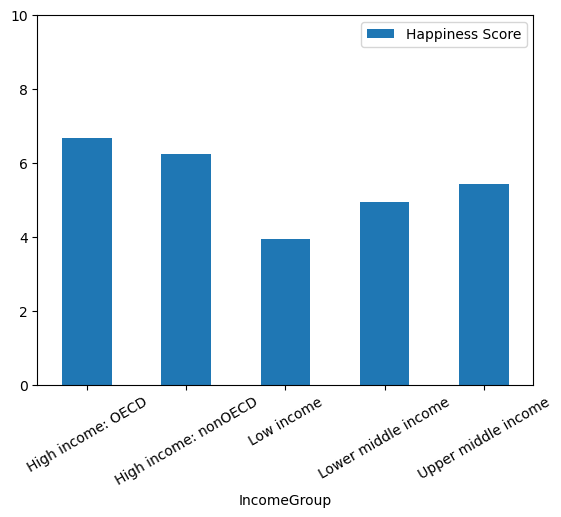

In [56]:
pv_incomes.plot(kind='bar', rot=30, ylim=(0,10))

| Método               | Descripción                                                                     |
|----------------------|---------------------------------------------------------------------------------|
| Series.str.split()   | Divide cada elemento de la Serie.                                               |
| Series.str.strip()   | Elimina los espacios en blanco de cada cadena en la Serie.                      |
| Series.str.lower()   | Convierte las cadenas de la Serie a minúsculas.                                 |
| Series.str.upper()   | Convierte las cadenas de la Serie a mayúsculas.                                 |
| Series.str.get()     | Recupera el i-ésimo elemento de cada elemento de la Serie.                      |
| Series.str.replace() | Reemplaza una expresión regular o una cadena en la Serie con otra cadena.       |
| Series.str.cat()     | Concatena cadenas en una Serie.                                                 |
| Series.str.extract() | Extrae subcadenas de la serie que coinciden con un patrón de expresión regular. |

### Ejercicio

Como recordatorio, nos gustaría limpiar los valores en la columna `IncomeGroup` a un formato estandarizado que se muestra en la tabla a continuación.

| Valor actual         | Valor transformado |
|----------------------|--------------------|
| Upper middle income  | UPPER MIDDLE       |
| Lower middle income  | LOWER MIDDLE       |
| High income: OECD    | HIGH OECD          |
| Low income           | LOW                |
| High income: nonOECD | HIGH NONOECD       |

*   Use algunos de los métodos de cadena anteriores para limpiar la columna `IncomeGroup`.
    *   Asegúrese de eliminar los espacios en blanco al final de las cadenas.
*   Use el método `df.pivot_table()` para devolver la media de cada grupo de ingresos en la columna `IncomeGroup`. Establezca el parámetro `index` igual a la columna `IncomeGroup` y el parámetro `values` igual a la columna `Happiness Score`. Asigne el resultado a `pv_incomes`.
*   Utilice el método `df.plot()` para trazar los resultados. Establezca el parámetro `kind` igual a `bar`, el parámetro `rot` igual a `30` y el parámetro `ylim` igual a `(0,10)`.

In [57]:
actual_values = merged['IncomeGroup'].unique().tolist()

In [58]:
print(actual_values)

['High income: OECD', 'Upper middle income', 'High income: nonOECD', nan, 'Lower middle income', 'Low income']


In [59]:
updated_values = ['HIGH OECD',
 'UPPER MIDDLE',
 'HIGH NONOECD',
 np.nan,
 'LOWER MIDDLE',
 'LOW']

In [60]:
new_values_dict = dict(zip(actual_values, updated_values))

In [61]:
merged['IncomeGroup']

Country
Switzerland    High income: OECD
Iceland        High income: OECD
Denmark        High income: OECD
Norway         High income: OECD
Canada         High income: OECD
                     ...        
Rwanda                Low income
Benin                 Low income
Syria                        NaN
Burundi               Low income
Togo                  Low income
Name: IncomeGroup, Length: 158, dtype: object

In [62]:
merged['IncomeGroup'] = merged['IncomeGroup'].map(new_values_dict)

In [63]:
merged['IncomeGroup'].head()

Country
Switzerland    HIGH OECD
Iceland        HIGH OECD
Denmark        HIGH OECD
Norway         HIGH OECD
Canada         HIGH OECD
Name: IncomeGroup, dtype: object

In [64]:
pv_incomes = pd.pivot_table(
    data=merged,
    index='IncomeGroup', 
    values='Happiness Score',
#   aggfunc=np.mean,
    )

<Axes: xlabel='IncomeGroup'>

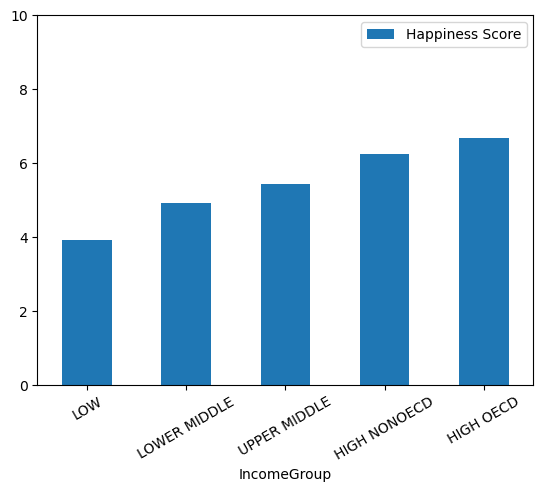

In [65]:
pv_incomes.sort_values(by='Happiness Score').plot(
        kind='bar', 
        rot=30, 
        ylim=(0,10)
    )

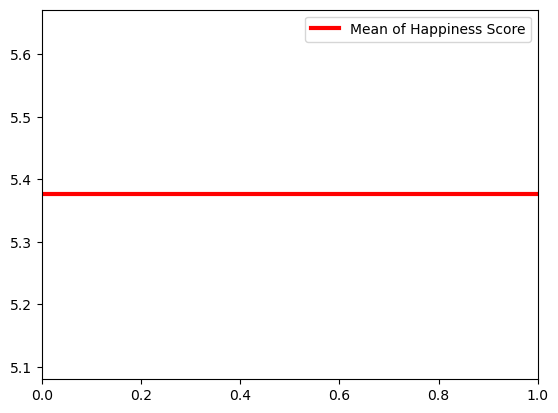

In [66]:
plt.axhline(
    merged['Happiness Score'].mean(), 
    color='red', 
    lw=3, 
    label='Mean of Happiness Score',
  )

plt.legend()
plt.show()